# Assignment 1 — 02: Exploratory Data Analysis

**KQC7016 Data Analytics | Theme 7: Autonomous Driving**  
**Group:** Muhammad Amru Bin Mohamad Sharis (S2116804) & Nor Shahadah Fitrah Binti Ramani (25073210)

## Purpose
Explore the cleaned NHTSA SGO AV incident dataset to surface patterns, anomalies, and the visual evidence for the two hypotheses tested in `03_stats`.

## Plots produced (11)
1. Top manufacturers (system-coloured)
2. ADS vs ADAS distribution
3. Incidents over time
4. Roadway type by system *(H1 visualisation)*
5. Injury severity by system *(H2 visualisation)*
6. Top crash objects
7. Weather conditions
8. Lighting conditions (prior-schema subset)
9. Roadway × Lighting heatmap
10. Precrash speed by roadway type
11. Numeric correlation heatmap

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv('data/cleaned.csv', low_memory=False)

# Normalise JLR -> JAGUAR (same fleet, Waymo Jaguar Land Rover I-PACE)
df['Make_clean'] = df['Make_clean'].replace({'JLR': 'JAGUAR'})

# Restrict to known system type for system-comparison plots
df_sys = df[df['System_type'].isin(['ADS', 'ADAS'])].copy()
print(f'Total rows: {len(df)}  |  ADS/ADAS subset: {len(df_sys)}')

Total rows: 6450  |  ADS/ADAS subset: 6219


## 2. Summary statistics

In [2]:
num_cols = ['SV Precrash Speed (MPH)', 'Posted Speed Limit (MPH)', 'Severity_num', 'Model Year', 'Year']
df[num_cols].describe().round(2)

,SV Precrash Speed (MPH),Posted Speed Limit (MPH),Severity_num,Model Year,Year
count,5912.00,4060.00,2364.00,6436.00,6430.00
mean,26.84,43.06,0.35,2022.13,2023.91
std,30.40,18.05,0.89,2.26,1.37
min,0.00,0.00,0.00,2014.00,2019.00
25%,0.00,25.00,0.00,2021.00,2023.00
50%,20.00,40.00,0.00,2023.00,2024.00
75%,48.00,65.00,0.00,2024.00,2025.00
max,925.00,80.00,4.00,2026.00,2026.00


In [3]:
df[['System_type', 'Make_clean', 'Roadway Type', 'Weather_condition', 'Lighting']].describe(include='all')

,System_type,Make_clean,Roadway Type,Weather_condition,Lighting
count,6450,6450,6450,5067,4570
unique,3,61,9,5,7
top,ADAS,TESLA,Street,Clear,Daylight
freq,3549,3214,2004,3664,2163


## Plot 1 — Top 8 manufacturers by system type
Tesla dominates ADAS reports (Autopilot / FSD Beta); Jaguar dominates ADS reports (Waymo's I-PACE robotaxi platform). Cruise (GM robotaxi) is third.

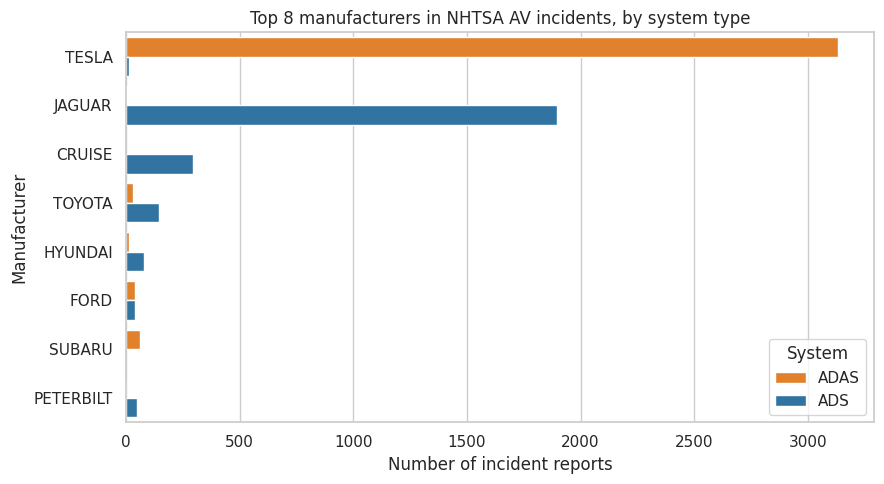

In [4]:
top_makes = df_sys['Make_clean'].value_counts().head(8).index
tmp = df_sys[df_sys['Make_clean'].isin(top_makes)]
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=tmp, y='Make_clean', hue='System_type',
              order=top_makes, palette={'ADS': '#1f77b4', 'ADAS': '#ff7f0e'}, ax=ax)
ax.set_title('Top 8 manufacturers in NHTSA AV incidents, by system type')
ax.set_xlabel('Number of incident reports')
ax.set_ylabel('Manufacturer')
ax.legend(title='System')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_top_makes.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 — System type distribution
Overall ADS vs ADAS split in the dataset.

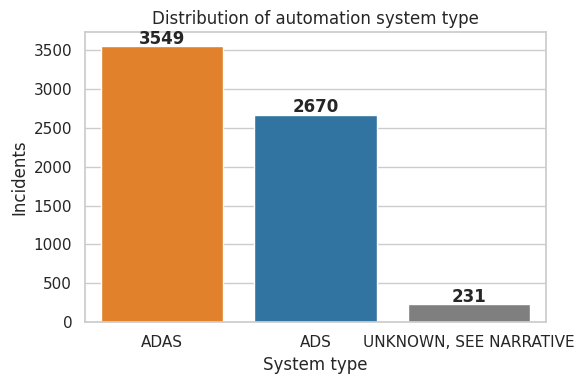

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
order = df['System_type'].value_counts().index
sns.countplot(data=df, x='System_type', order=order,
              palette=['#ff7f0e', '#1f77b4', '#7f7f7f'], ax=ax)
for i, v in enumerate(df['System_type'].value_counts().values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
ax.set_title('Distribution of automation system type')
ax.set_xlabel('System type')
ax.set_ylabel('Incidents')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_system_type.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 — Incidents over time
Monthly trend grouped by system type. Highlights rising AV reporting volume since 2022 and divergence between ADS and ADAS.

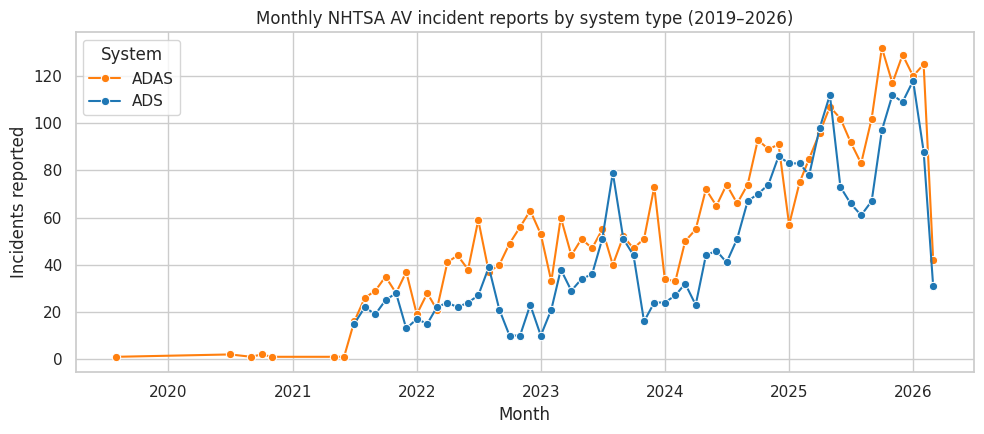

In [6]:
tmp = df_sys.dropna(subset=['Incident_Date_parsed']).copy()
tmp['YearMonth'] = pd.to_datetime(tmp['Incident_Date_parsed']).dt.to_period('M').dt.to_timestamp()
trend = tmp.groupby(['YearMonth', 'System_type']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(data=trend, x='YearMonth', y='count', hue='System_type',
             palette={'ADS': '#1f77b4', 'ADAS': '#ff7f0e'}, marker='o', ax=ax)
ax.set_title('Monthly NHTSA AV incident reports by system type (2019–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Incidents reported')
ax.legend(title='System')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_trend_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 — Roadway type by system *(H1 visual)*
Visualises the contingency that drives Hypothesis 1: ADAS incidents concentrate on highways/freeways; ADS incidents concentrate on streets, intersections, and parking lots.

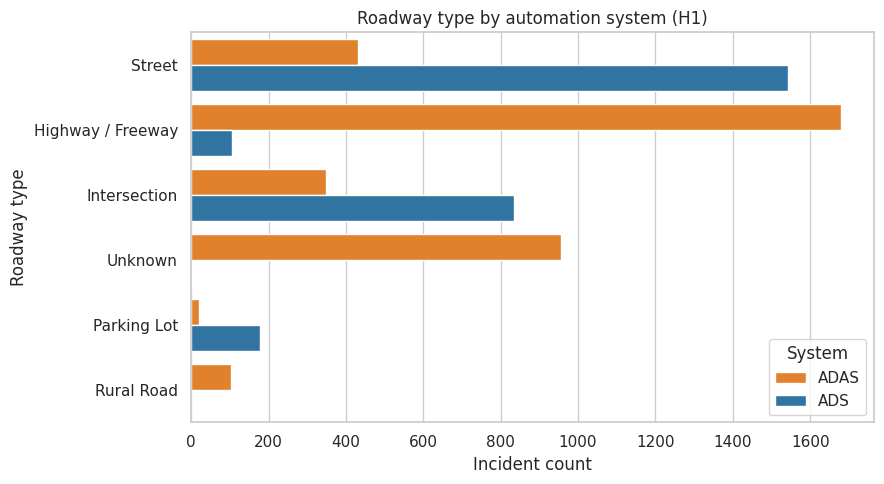

In [7]:
rw = df_sys.dropna(subset=['Roadway Type'])
main_rw = rw['Roadway Type'].value_counts().head(6).index
rw = rw[rw['Roadway Type'].isin(main_rw)]

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=rw, y='Roadway Type', hue='System_type', order=main_rw,
              palette={'ADS': '#1f77b4', 'ADAS': '#ff7f0e'}, ax=ax)
ax.set_title('Roadway type by automation system (H1)')
ax.set_xlabel('Incident count')
ax.set_ylabel('Roadway type')
ax.legend(title='System')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_roadway_by_system.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 5 — Injury severity by system *(H2 visual)*
Severity rates as percentages within each system (only rows with known severity). The bulk of ADS incidents are no-injury events; ADAS shows a larger Minor/Moderate share and the few fatalities present in the dataset.

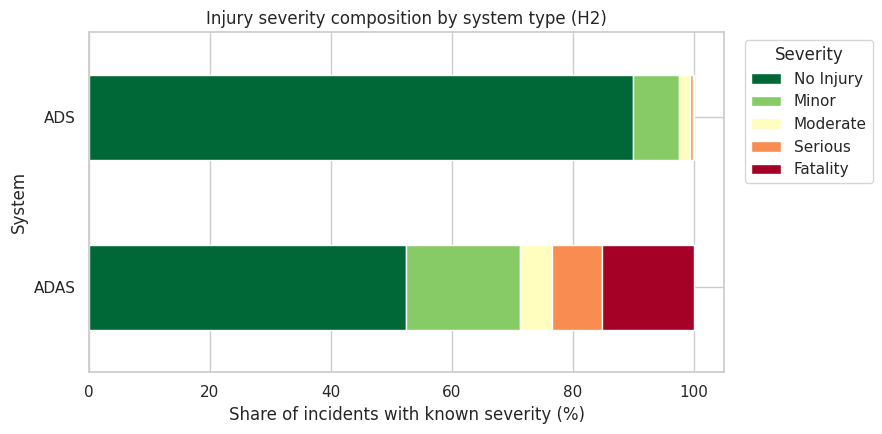

Effective N for severity comparison:
System_type
ADS     1822
ADAS     382
Name: count, dtype: int64


In [8]:
SEV_LABEL = {0: 'No Injury', 1: 'Minor', 2: 'Moderate', 3: 'Serious', 4: 'Fatality'}
sev = df_sys.dropna(subset=['Severity_num']).copy()
sev['Severity_label'] = sev['Severity_num'].map(SEV_LABEL)
ct = pd.crosstab(sev['System_type'], sev['Severity_label'],
                 normalize='index').loc[:, list(SEV_LABEL.values())] * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ct.plot(kind='barh', stacked=True, colormap='RdYlGn_r', ax=ax)
ax.set_title('Injury severity composition by system type (H2)')
ax.set_xlabel('Share of incidents with known severity (%)')
ax.set_ylabel('System')
ax.legend(title='Severity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_severity_by_system.png', dpi=150, bbox_inches='tight')
plt.show()

print('Effective N for severity comparison:')
print(sev['System_type'].value_counts())

## Plot 6 — Top crash objects
What AV-equipped vehicles most often collide with.

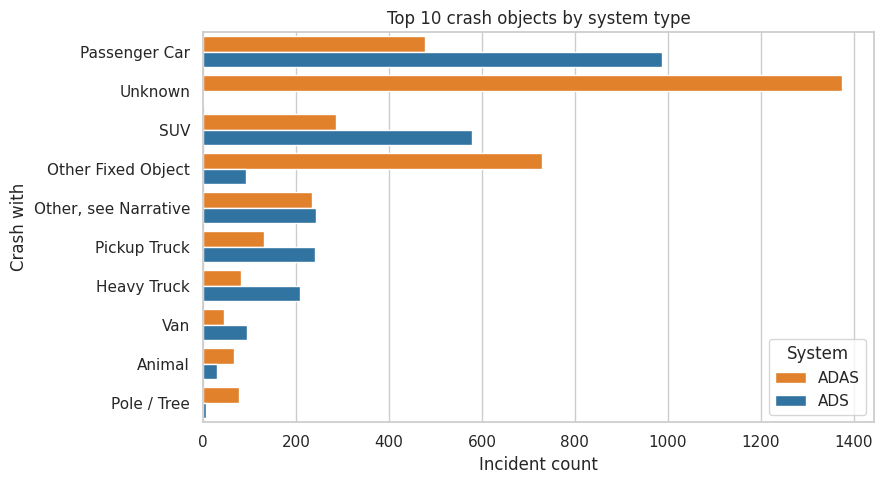

In [9]:
cw = df_sys.dropna(subset=['Crash With'])
top_cw = cw['Crash With'].value_counts().head(10).index

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=cw[cw['Crash With'].isin(top_cw)], y='Crash With',
              hue='System_type', order=top_cw,
              palette={'ADS': '#1f77b4', 'ADAS': '#ff7f0e'}, ax=ax)
ax.set_title('Top 10 crash objects by system type')
ax.set_xlabel('Incident count')
ax.set_ylabel('Crash with')
ax.legend(title='System')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_crash_with.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 7 — Weather conditions

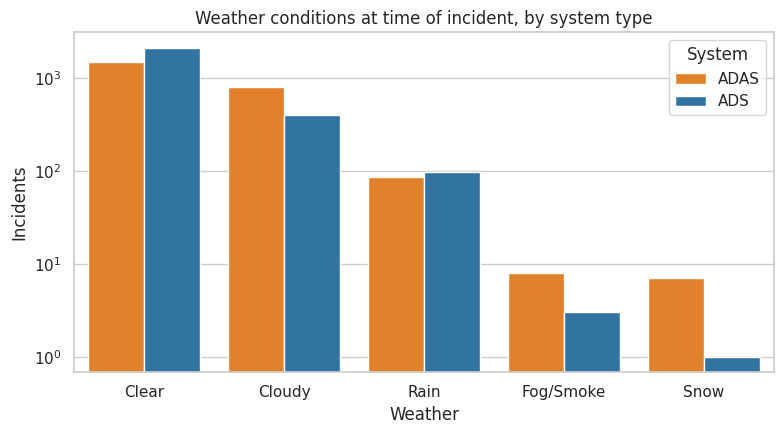

In [10]:
wx = df_sys.dropna(subset=['Weather_condition'])
order_wx = wx['Weather_condition'].value_counts().index

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=wx, x='Weather_condition', hue='System_type',
              order=order_wx, palette={'ADS': '#1f77b4', 'ADAS': '#ff7f0e'}, ax=ax)
ax.set_title('Weather conditions at time of incident, by system type')
ax.set_xlabel('Weather')
ax.set_ylabel('Incidents')
ax.set_yscale('log')
ax.legend(title='System')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '07_weather.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 8 — Lighting conditions (prior-schema subset)
Lighting is only recorded in the prior-schema files (2019–mid 2025); the newer NHTSA submission template dropped this field. Analysis here is scoped to the rows where the field is present.

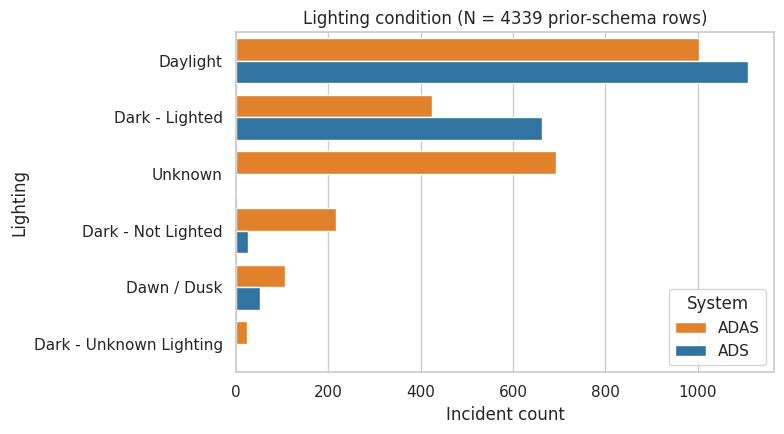

In [11]:
lt = df_sys.dropna(subset=['Lighting'])
order_lt = lt['Lighting'].value_counts().head(6).index

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=lt[lt['Lighting'].isin(order_lt)], y='Lighting',
              hue='System_type', order=order_lt,
              palette={'ADS': '#1f77b4', 'ADAS': '#ff7f0e'}, ax=ax)
ax.set_title(f'Lighting condition (N = {len(lt)} prior-schema rows)')
ax.set_xlabel('Incident count')
ax.set_ylabel('Lighting')
ax.legend(title='System')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '08_lighting.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 9 — Roadway × Lighting heatmap
Compound-condition view: where do incidents cluster when both road type and lighting are known?

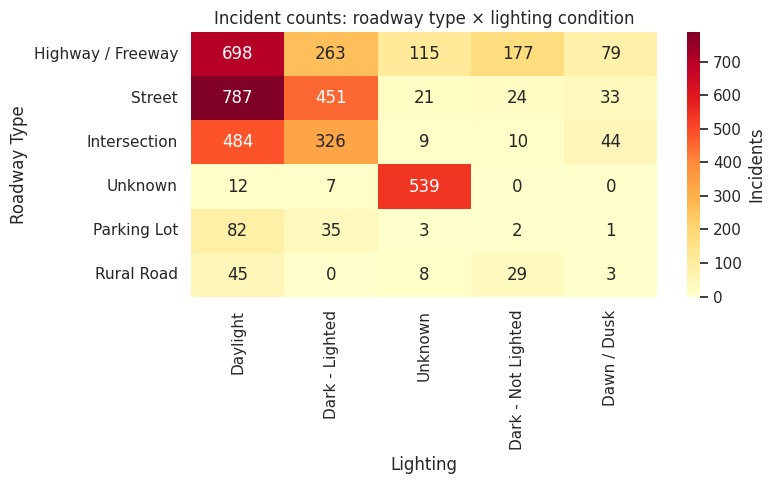

In [12]:
rl = df_sys.dropna(subset=['Roadway Type', 'Lighting'])
top_rw = rl['Roadway Type'].value_counts().head(6).index
top_lt = rl['Lighting'].value_counts().head(5).index
rl = rl[rl['Roadway Type'].isin(top_rw) & rl['Lighting'].isin(top_lt)]
heat = pd.crosstab(rl['Roadway Type'], rl['Lighting']).loc[top_rw, top_lt]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Incidents'}, ax=ax)
ax.set_title('Incident counts: roadway type × lighting condition')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '09_roadway_lighting_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 10 — Precrash speed by roadway type
Speed context for incidents — highways/freeways unsurprisingly show higher precrash speeds than streets, intersections, and parking lots.

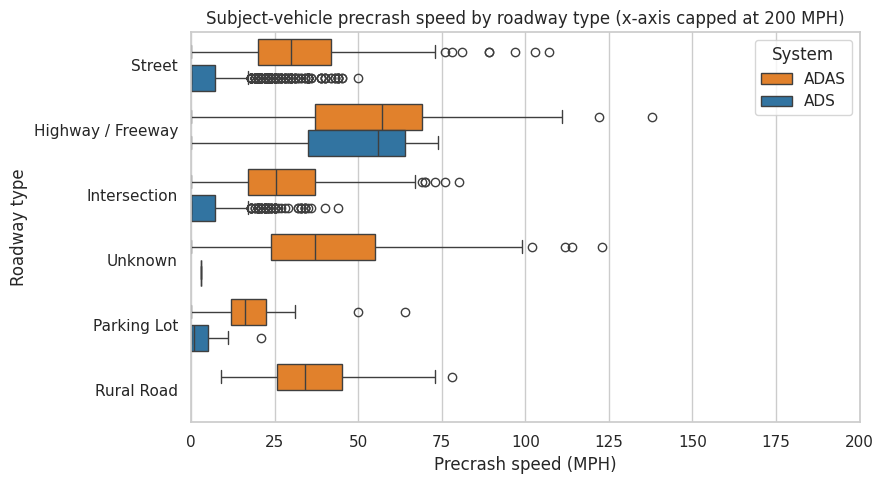

In [13]:
sp = df_sys.dropna(subset=['SV Precrash Speed (MPH)', 'Roadway Type']).copy()
top_rw = sp['Roadway Type'].value_counts().head(6).index
sp = sp[sp['Roadway Type'].isin(top_rw)]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=sp, x='SV Precrash Speed (MPH)', y='Roadway Type',
            hue='System_type', order=top_rw,
            palette={'ADS': '#1f77b4', 'ADAS': '#ff7f0e'}, ax=ax)
# Cap x-axis at 200 MPH; a handful of >200 MPH records appear to be data-entry
# errors (the dataset's max is 925) and stretch the visual unnecessarily.
ax.set_xlim(0, 200)
ax.set_title('Subject-vehicle precrash speed by roadway type (x-axis capped at 200 MPH)')
ax.set_xlabel('Precrash speed (MPH)')
ax.set_ylabel('Roadway type')
ax.legend(title='System')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '10_speed_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 11 — Numeric correlation heatmap
Pearson correlation across the numeric analytical columns. Most pairs show weak correlation; the strongest is the natural relationship between precrash speed and posted speed limit.

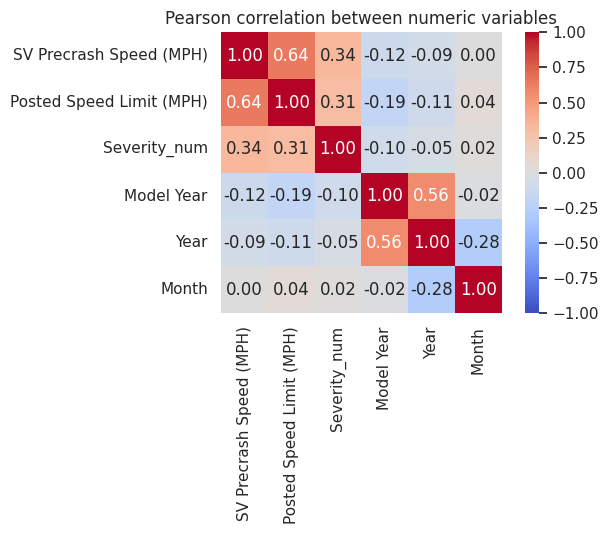

In [14]:
corr = df_sys[['SV Precrash Speed (MPH)', 'Posted Speed Limit (MPH)',
               'Severity_num', 'Model Year', 'Year', 'Month']].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Pearson correlation between numeric variables')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '11_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA summary

Key patterns observed (interpreted in detail in the report):

1. **Fleet composition is bimodal.** Tesla dominates ADAS reports; Jaguar (Waymo's I-PACE) and Cruise dominate ADS reports.
2. **Reporting volume grew sharply post-2022** — driven by Waymo and Cruise commercial expansion plus higher Tesla Autopilot mileage.
3. **ADS and ADAS operate in different domains.** ADAS incidents concentrate on highways/freeways; ADS incidents concentrate on streets, intersections, and parking lots — direct evidence motivating H1.
4. **Severity distributions differ.** Most ADS incidents are no-injury; ADAS shows a heavier Minor/Moderate share and the bulk of the fatal events. Motivates H2 (with the confound caveat below).
5. **Weather and lighting effects are limited by data sparsity** — adverse weather and dark conditions are rare across the dataset; conclusions in those slices are descriptive only.
6. **Speed context** — precrash speed cleanly stratifies by roadway type, confirming the operational-domain split between ADS and ADAS.

**Confound to carry into `03_stats`:** the ADS vs ADAS comparison entangles system type with operational domain (Tesla highways vs Waymo urban). All causal claims are framed as descriptive associations, not safety conclusions.

Next: `03_stats.ipynb` — chi-square (H1) and Mann-Whitney U (H2).